# Notebook 06 — Chạy lại toàn bộ Project 4 bằng ENGINE v2

**Mục đích**: thay thế các con số Sharpe cũ (tính bằng engine có look-ahead cùng ngày) bằng số liệu mới, đồng thời **đo mức chênh** giữa engine cũ và engine v2 trên CÙNG dữ liệu, CÙNG tham số.

| Thay đổi so với Ngày 19-22 | Trước | Sau (v2) |
|---|---|---|
| Thời điểm ăn return | vị thế vừa mở/đóng ở close `t` vẫn ăn/né return ngày `t` | signal chốt close `t` → vị thế ăn return từ `t+1`; vị thế bị đóng ở `t` vẫn ăn return ngày `t` |
| Walk-forward XGBoost | train mọi ngày `< t` (nhãn 5 ngày cuối chứa giá sau `t`) | train chỉ `≤ t − N_FWD − 1` (purge nhãn) |
| Cắt warm-up | `ret[ret != 0]` (lọc theo giá trị) | `invested_returns()` (cắt theo ngày có vị thế thật) |

**Cách đọc kết quả**
- `Δ legacy − v2` là *lượng Sharpe do lỗi look-ahead thổi phồng* trên dữ liệu thật của bạn. Nếu `|Δ|` nhỏ hơn ~2 `Sharpe SE` thì chênh lệch không phân biệt được với nhiễu.
- `Sharpe SE` ≈ 0.5–0.7 với ~3 năm dữ liệu: **chênh lệch Sharpe giữa các chiến lược nhỏ hơn ~1.0 gần như chắc chắn là nhiễu**. Dùng `t(excess vs 1/N)` (kiểm định ghép cặp) để so với benchmark.
- Trọng số IC của Composite vẫn tính trên toàn mẫu (xem phần Hạn chế trong README).

## 1. Cấu hình + dữ liệu

In [1]:
# -*- coding: utf-8 -*-
import sys
sys.path.insert(0, "..")

import json
import warnings
from datetime import date
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import spearmanr

from launcher import build_factors
from src.backtest import TOTAL_COST_RATE, backtest_with_exits, calmar_ratio, invested_returns, port_metrics, sharpe_se, trade_statistics
from src.backtest_legacy import backtest_with_exits_legacy
from src.data_loader import VN30_UNIVERSE, filter_by_coverage, load_ohlcv
from src.feature_engineering import assemble_dataset, cross_sectional_rank
from src.ic_analysis import single_factor_ic
from src.model import fit_xgboost, walk_forward_signal
from src.momentum_factors import forward_return
from src.risk import compare_strategies, equal_weight_benchmark, excess_return_tstat
from src.strategy import composite_score, normalize_ic_weights

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", lambda x: f"{x:.4f}")
pd.set_option("display.width", 200)

N_FWD, START, END = 5, "2022-01-01", date.today().isoformat()
ENGINE_KW = dict(stop_loss_pct=0.08, trail_pct=0.12, vol_exit_thr=3.0, vol_reduce_thr=2.0,
                 top_entry_rank=0.65, signal_exit_rank=0.40, max_positions=10, rebal_freq=5, cost_rate=TOTAL_COST_RATE)
PALETTE = {"grey": "#8e99ad", "blue": "#5b6fa2", "navy": "#2b3d6f", "pink": "#fea7e9"}

In [2]:
ohlcv = load_ohlcv(VN30_UNIVERSE, START, END, fields=("close", "volume"))
price_df, dropped = filter_by_coverage(ohlcv["close"].dropna(how="all"))
volume_df = ohlcv["volume"][price_df.columns]
print(f"Universe {price_df.shape[1]} mã (loại {dropped}) | {price_df.index.min().date()} → {price_df.index.max().date()} | {len(price_df)} phiên")

[1/30] Loading ACB...


[2/30] Loading BID...
[3/30] Loading BSR...
[4/30] Loading CTG...
[5/30] Loading FPT...
[6/30] Loading GAS...
[7/30] Loading GVR...
[8/30] Loading HDB...
[9/30] Loading HPG...
[10/30] Loading LPB...
[11/30] Loading MBB...
[12/30] Loading MCH...
[13/30] Loading MSN...
[14/30] Loading MWG...
[15/30] Loading SAB...
[16/30] Loading SHB...
[17/30] Loading SSB...
[18/30] Loading SSI...
⏳ Nghỉ 65s để tránh rate limit...
[19/30] Loading STB...
[20/30] Loading TCB...
[21/30] Loading TCX...
[22/30] Loading VCB...
[23/30] Loading VHM...
[24/30] Loading VIB...
[25/30] Loading VIC...
[26/30] Loading VJC...
[27/30] Loading VNM...
[28/30] Loading VPB...
[29/30] Loading VPL...
[30/30] Loading VRE...

✅ Đã tải: 30/30 mã
Universe 28 mã (loại ['TCX', 'VPL']) | 2022-01-04 → 2026-10-02 | 1181 phiên


## 2. Signal: Composite (IC-weighted) · Single Factor · XGBoost walk-forward

XGBoost được tạo **2 lần**: `purged` (n_fwd=5, đúng) và `không purge` (n_fwd=0 = hành vi cũ) để đo riêng ảnh hưởng của lỗi nhãn chồng lấn.

In [3]:
raw_factors, vol_20, vol_120 = build_factors(price_df, volume_df)
vol_spike, mom_6_1, feature_cols = vol_20 / vol_120, raw_factors["Momentum_6_1"], list(raw_factors)

dataset = assemble_dataset(raw_factors, price_df, n_fwd=N_FWD, label_type="regression")
sf_ic = single_factor_ic(dataset, feature_cols, n_splits=5, embargo=5)
ic_w = normalize_ic_weights(sf_ic)
print("Single-factor OOF IC:", sf_ic.round(4).to_dict()); print("Trọng số IC:", {k: round(float(v), 3) for k, v in dict(ic_w).items()})

ranked = {n: cross_sectional_rank(f) for n, f in raw_factors.items()}
xgb_kw = dict(model_fn=fit_xgboost, retrain_every=21, min_train_days=252, n_estimators=200, max_depth=3, learning_rate=0.05)
signals = {
    "IC-Weighted Composite": composite_score(ranked, ic_w),
    "Single Factor (Mom_6_1)": ranked["Momentum_6_1"],
    "XGBoost walk-forward": walk_forward_signal(dataset, feature_cols, n_fwd=N_FWD, **xgb_kw),
}
xgb_no_purge = walk_forward_signal(dataset, feature_cols, n_fwd=0, **xgb_kw)           # hành vi CŨ, chỉ để so sánh

Single-factor OOF IC: {'Momentum_12_1': 0.0335, 'TS_Momentum': 0.0296, 'Momentum_6_1': 0.0241, 'Volume_Ratio': 0.0104}
Trọng số IC: {'Momentum_12_1': 0.344, 'TS_Momentum': 0.303, 'Momentum_6_1': 0.247, 'Volume_Ratio': 0.107}


## 3. Backtest engine v2 vs engine cũ — cùng dữ liệu, cùng tham số, cùng cost 0.23%

In [4]:
res_v2, trades_v2, res_old = {}, {}, {}
for name, sig in signals.items():
    p2, t2 = backtest_with_exits(price_df, sig, vol_spike, mom_6_1, **ENGINE_KW)
    res_v2[name], trades_v2[name] = p2, t2
    old_sig = xgb_no_purge if name.startswith("XGBoost") else sig                      # cũ = engine cũ (+ không purge với XGBoost)
    res_old[name], _ = backtest_with_exits_legacy(price_df, old_sig, vol_spike, mom_6_1, **ENGINE_KW)

ew_ret = equal_weight_benchmark(price_df)
ret_v2 = {n: invested_returns(p) for n, p in res_v2.items()}
common = ew_ret.index
for r in ret_v2.values():
    common = common.intersection(r.index)                                             # CÙNG cửa sổ cho mọi chiến lược
ret_v2 = {n: r.loc[common] for n, r in ret_v2.items()}
ret_old = {n: p["port_return"].reindex(common) for n, p in res_old.items()}
ew_c = ew_ret.loc[common]
print(f"Cửa sổ so sánh chung: {common.min().date()} → {common.max().date()} ({len(common)} phiên)")

rows = []
for n in signals:
    m2, mo = port_metrics(ret_v2[n]), port_metrics(ret_old[n])
    rows.append({"Chiến lược": n, "Sharpe (engine cũ)": mo["Sharpe"], "Sharpe (v2)": m2["Sharpe"],
                 "Δ cũ − v2": mo["Sharpe"] - m2["Sharpe"], "Sharpe SE": sharpe_se(ret_v2[n])})
engine_gap = pd.DataFrame(rows).set_index("Chiến lược")
print("\nMức Sharpe bị thổi phồng bởi engine cũ (trên dữ liệu thật):")
display(engine_gap)

Cửa sổ so sánh chung: 2024-01-12 → 2026-09-25 (670 phiên)

Mức Sharpe bị thổi phồng bởi engine cũ (trên dữ liệu thật):


,Sharpe (engine cũ),Sharpe (v2),Δ cũ − v2,Sharpe SE
Chiến lược,,,,
IC-Weighted Composite,1.9411,1.1583,0.7828,0.6141
Single Factor (Mom_6_1),2.1800,1.4898,0.6902,0.6145
XGBoost walk-forward,2.0615,1.5118,0.5498,0.6145


## 4. Bảng kết quả engine v2 (net cost) — dùng cho README

In [5]:
def daily_rank_ic(sig: pd.DataFrame, fwd: pd.DataFrame, idx: pd.Index) -> pd.Series:
    out = {}
    for d in idx.intersection(sig.index).intersection(fwd.index):
        s, f = sig.loc[d], fwd.loc[d]
        ok = s.notna() & f.notna()
        if ok.sum() >= 5:
            out[d] = spearmanr(s[ok], f[ok])[0]
    return pd.Series(out).dropna()


fwd = forward_return(price_df, N_FWD)
strategies = {f"{n} (net)": r for n, r in ret_v2.items()}
strategies["1/N Equal-Weight"] = ew_c
cmp_v2 = compare_strategies(strategies)

extra = {}
for n in signals:
    ic = daily_rank_ic(signals[n], fwd, common)
    ts = trade_statistics(trades_v2[n])
    extra[f"{n} (net)"] = {
        "Rank IC": ic.mean(), "t(IC, adj)": ic.mean() / ic.std() * np.sqrt(len(ic) / N_FWD),
        "t(excess vs 1/N)": excess_return_tstat(ret_v2[n], ew_c),
        "Gross Sharpe": port_metrics(invested_returns(res_v2[n], "gross_return").loc[common])["Sharpe"],
        "Cost đã trả": res_v2[n]["cost"].loc[common].sum(), "Số lệnh BUY": ts.get("n_buys"),
        "Hold TB (ngày)": ts.get("avg_hold_days"), "Win rate": ts.get("win_rate"),
    }
table = cmp_v2.join(pd.DataFrame(extra).T)
display(table)
print("\nExit breakdown (engine v2):")
for n in signals:
    print(f"  {n:<26}", trade_statistics(trades_v2[n]).get("exit_breakdown", {}))

,Total Return,Ann Return,Ann Vol,Sharpe,Max DD,Calmar,Sharpe SE,Rank IC,"t(IC, adj)",t(excess vs 1/N),Gross Sharpe,Cost đã trả,Số lệnh BUY,Hold TB (ngày),Win rate
IC-Weighted Composite (net),0.8031,0.2482,0.2143,1.1583,-0.2336,1.0625,0.6141,0.0442,1.8717,0.1124,1.4061,0.1060,290.0000,41.1993,0.4895
Single Factor (Mom_6_1) (net),1.0656,0.3137,0.2106,1.4898,-0.1887,1.6621,0.6145,0.0176,0.7221,0.9703,1.7083,0.0862,289.0000,45.8481,0.5230
XGBoost walk-forward (net),1.1923,0.3434,0.2272,1.5118,-0.2065,1.6633,0.6145,0.0223,1.1693,1.1301,2.1819,0.2809,442.0000,14.9909,0.4909
1/N Equal-Weight,0.8003,0.2475,0.1839,1.3458,-0.1675,1.4773,0.6143,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Exit breakdown (engine v2):
  IC-Weighted Composite      {'MOM_FLIP': 122, 'HARD_STOP': 65, 'TRAILING_STOP': 55, 'SIGNAL_EXIT': 38, 'VOL_REDUCE': 6}
  Single Factor (Mom_6_1)    {'MOM_FLIP': 98, 'HARD_STOP': 73, 'TRAILING_STOP': 66, 'SIGNAL_EXIT': 42, 'VOL_REDUCE': 4}
  XGBoost walk-forward       {'SIGNAL_EXIT': 307, 'MOM_FLIP': 71, 'HARD_STOP': 39, 'TRAILING_STOP': 16, 'VOL_REDUCE': 5}


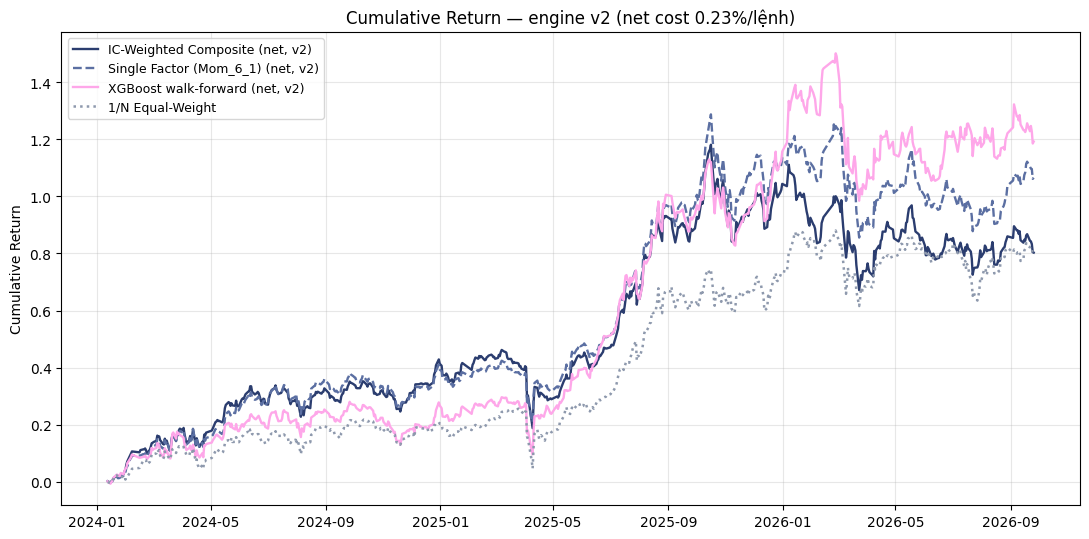

In [6]:
fig, ax = plt.subplots(figsize=(11, 5.5))
styles = [("IC-Weighted Composite", PALETTE["navy"], "-"), ("Single Factor (Mom_6_1)", PALETTE["blue"], "--"),
          ("XGBoost walk-forward", PALETTE["pink"], "-")]
for n, c, ls in styles:
    cum = (1 + ret_v2[n]).cumprod() - 1
    ax.plot(cum.index, cum.values, label=f"{n} (net, v2)", color=c, linestyle=ls, linewidth=1.7)
cum_ew = (1 + ew_c).cumprod() - 1
ax.plot(cum_ew.index, cum_ew.values, label="1/N Equal-Weight", color=PALETTE["grey"], linestyle=":", linewidth=1.8)
ax.set_title("Cumulative Return — engine v2 (net cost 0.23%/lệnh)"); ax.set_ylabel("Cumulative Return")
ax.legend(fontsize=9); ax.grid(True, alpha=0.3); plt.tight_layout()
Path("../reports").mkdir(exist_ok=True)
plt.savefig("../reports/engine_v2_cumulative.png", dpi=120, bbox_inches="tight"); plt.show()

## 5. Kết luận in từ số liệu + lưu kết quả

In [7]:
ew_s = cmp_v2.loc["1/N Equal-Weight", "Sharpe"]
print("=" * 84); print("KẾT LUẬN — ENGINE v2 (net cost), cùng cửa sổ", common.min().date(), "→", common.max().date()); print("=" * 84)
for n in signals:
    k = f"{n} (net)"
    r = table.loc[k]
    verdict = "CÓ ý nghĩa" if r["t(excess vs 1/N)"] >= 2 else "chưa khác 1/N có ý nghĩa thống kê"
    print(f"  {n:<26} Sharpe {r['Sharpe']:+.2f} ± {1.96 * r['Sharpe SE']:.2f} | vs 1/N {ew_s:+.2f} | t(excess) {r['t(excess vs 1/N)']:+.2f} → {verdict}")
best = table.loc[[f"{n} (net)" for n in signals], "Sharpe"].idxmax()
print(f"\nSharpe cao nhất: {best}. Khoảng cách giữa các chiến lược ML/composite so với SE ({table['Sharpe SE'].mean():.2f}): "
      f"{'KHÔNG phân biệt được' if table.loc[[f'{n} (net)' for n in signals], 'Sharpe'].max() - table.loc[[f'{n} (net)' for n in signals], 'Sharpe'].min() < 2 * table['Sharpe SE'].mean() else 'có thể phân biệt'}.")
print(f"\nMức thổi phồng của engine cũ (Δ cũ − v2): " + ", ".join(f"{n} {engine_gap.loc[n, 'Δ cũ − v2']:+.2f}" for n in signals))
print("\nLưu ý: trọng số IC tính trên toàn mẫu; tham số PositionManager cố định (chưa có out-of-sample tách biệt); cost cố định 0.23%.")

out = {"engine": "v2", "window": [str(common.min().date()), str(common.max().date())], "n_days": int(len(common)),
       "cost_rate": TOTAL_COST_RATE, "universe": list(price_df.columns),
       "table": json.loads(table.to_json(orient="index")), "engine_gap": json.loads(engine_gap.to_json(orient="index"))}
Path("../reports").mkdir(exist_ok=True)
Path("../reports/results_engine_v2.json").write_text(json.dumps(out, ensure_ascii=False, indent=2), encoding="utf-8")
print("\nĐã lưu reports/results_engine_v2.json — copy các số này vào README (mục 'Kết quả engine v2').")

KẾT LUẬN — ENGINE v2 (net cost), cùng cửa sổ 2024-01-12 → 2026-09-25
  IC-Weighted Composite      Sharpe +1.16 ± 1.20 | vs 1/N +1.35 | t(excess) +0.11 → chưa khác 1/N có ý nghĩa thống kê
  Single Factor (Mom_6_1)    Sharpe +1.49 ± 1.20 | vs 1/N +1.35 | t(excess) +0.97 → chưa khác 1/N có ý nghĩa thống kê
  XGBoost walk-forward       Sharpe +1.51 ± 1.20 | vs 1/N +1.35 | t(excess) +1.13 → chưa khác 1/N có ý nghĩa thống kê

Sharpe cao nhất: XGBoost walk-forward (net). Khoảng cách giữa các chiến lược ML/composite so với SE (0.61): KHÔNG phân biệt được.

Mức thổi phồng của engine cũ (Δ cũ − v2): IC-Weighted Composite +0.78, Single Factor (Mom_6_1) +0.69, XGBoost walk-forward +0.55

Lưu ý: trọng số IC tính trên toàn mẫu; tham số PositionManager cố định (chưa có out-of-sample tách biệt); cost cố định 0.23%.

Đã lưu reports/results_engine_v2.json — copy các số này vào README (mục 'Kết quả engine v2').
